In [ ]:
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import phi2D_utilities as utils;
import gysela_utilities as gys_utils;
from scipy.signal import hilbert;

# Styling.
plt.style.use("bmh");

In [2]:
# Test inputs - delete when done!
directory_path = "C:/Workspace/NSCC/local copies/raw_output_data/DN_DAYCASE_DELTASCAN_255X512_Q3.5_-0.3";
data_arrays = reader.fetch_phi2D_data(directory_path, parallelise = False);
dt_diag = reader.fetch_dt_diag(directory_path);
jacobian_dictionary = reader.fetch_jacobian(directory_path);
aspect_ratio = reader.fetch_aspect_ratio(directory_path);
safety_factor = reader.fetch_safety_factor_flat(directory_path);

Found 1501 files in the directory. Beginning compilation...
Compiled data from 1000 files...
Finished compiling data from all files in the directory.


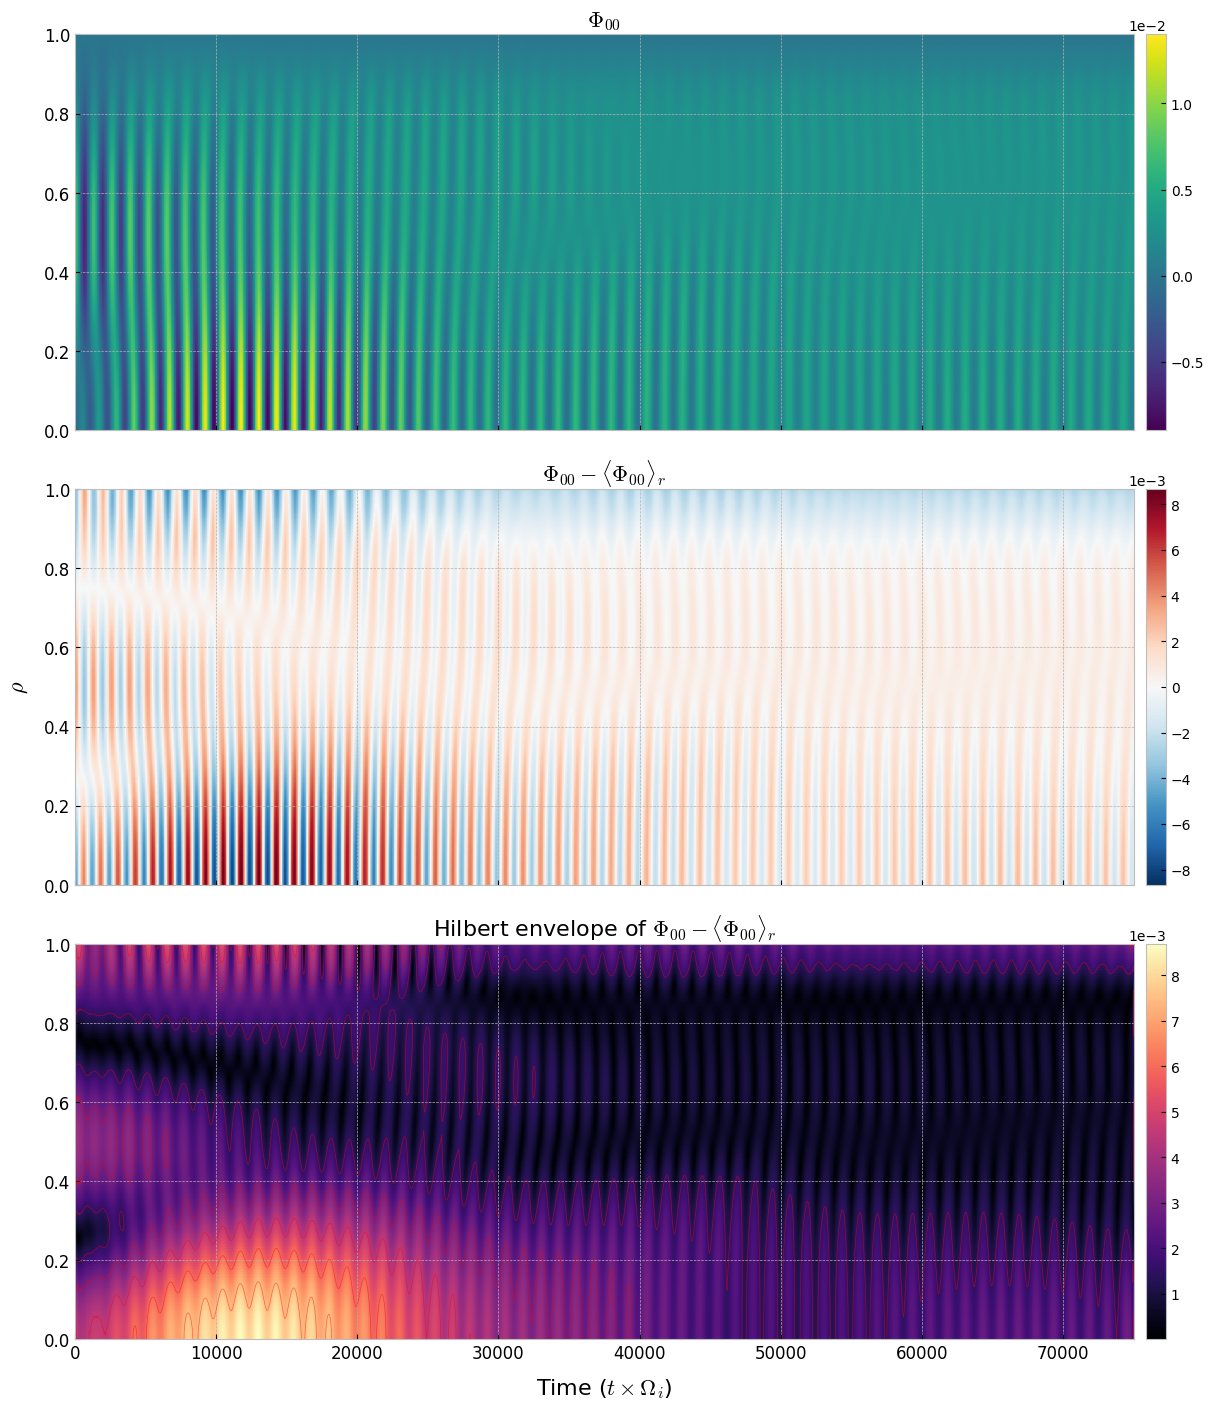

In [15]:
def plot_gam_hovmoller(phi2D_list, dt_diag, jacobian_dictionary):

	fs_avg_time_series = utils.generate_poloidally_averaged_time_series(phi2D_list, jacobian_dictionary, effective_radius = None);
	radially_averaged_time_series = gys_utils.radial_average_1D(fs_avg_time_series, jacobian_dictionary);

	raw_signal = fs_avg_time_series.values;
	gam_signal = (fs_avg_time_series - radially_averaged_time_series).values;
	gam_envelope = np.abs(hilbert(gam_signal, axis = 0));

	time_axis = gys_utils.generate_time_range_by_series(raw_signal, dt_diag);
	r_axis = fs_avg_time_series.coords["r"].values;
	rho_axis = r_axis / max(r_axis);
	
	fig, axes = plt.subplots(3, 1, figsize = (14, 15), sharex = True, gridspec_kw = {'hspace': 0.15});
	# Panel 1: Phi_00.
	mesh1 = axes[0].pcolormesh(time_axis, rho_axis, raw_signal.T, cmap="viridis", shading="auto")
	axes[0].set_title(r"$\Phi_{00}$", fontsize=16);
	fig.colorbar(mesh1, ax = axes[0], pad = 0.01).formatter.set_powerlimits((0, 0));
	# Panel 2: GAM signal.
	vmax_gam = np.abs(gam_signal).max();
	mesh2 = axes[1].pcolormesh(time_axis, rho_axis, gam_signal.T, cmap="RdBu_r", vmin = -vmax_gam, vmax = vmax_gam, shading = "auto");
	axes[1].set_title(r"$\Phi_{00} - \langle \Phi_{00} \rangle_r$", fontsize = 16);
	axes[1].set_ylabel(r"$\rho$", fontsize = 16, labelpad = 10);
	fig.colorbar(mesh2, ax=axes[1], pad=0.01).formatter.set_powerlimits((0, 0));

	# Panel 3: Hilbert envelope. Used for tracking propagation.
	mesh3 = axes[2].pcolormesh(time_axis, rho_axis, gam_envelope.T, cmap = "magma", shading = "auto");
	axes[2].set_title(r"Hilbert envelope of $\Phi_{00} - \langle \Phi_{00} \rangle_r$", fontsize = 16);
	axes[2].set_xlabel(r"Time ($t \times \Omega_i$)", fontsize = 16, labelpad = 10);
	fig.colorbar(mesh3, ax = axes[2], pad = 0.01).formatter.set_powerlimits((0, 0));

	# Overlays a contour on the envelope.
	axes[2].contour(time_axis, rho_axis, gam_envelope.T, levels = 5, colors = "red", alpha = 0.5, linewidths = 0.5);

	for ax in axes:
		ax.set_ylim(rho_axis.min(), rho_axis.max());
		ax.set_xlim(0, time_axis[-1]);
		ax.tick_params(axis="both", which="major", labelsize=12);

	plt.subplots_adjust(top=0.95, bottom=0.08, left=0.08, right=0.98);
	plt.show();

plot_gam_hovmoller(data_arrays, dt_diag, jacobian_dictionary);